# Breast Cancer Classification Pipeline

In [30]:
%pip install matplotlib pandas scikit-learn ucimlrepo seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, roc_curve, auc


# Dataset: Wisconsin (Diagnostic)

## Built in Scikit-learn

In [32]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print(f"Breast cancer dataset: {X.shape[0]} samples, {X.shape[1]} features")

Breast cancer dataset: 569 samples, 30 features


## Preprocessing and train/test split (80-20)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Model pipeline: MLP CLassifier

In [34]:
mlp_pipe = Pipeline([
	("scaler", StandardScaler()),
	("mlp", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, verbose=True))
])

## Model pipeline: SVM

In [ ]:
svm_pipe = Pipeline([
	("scaler", StandardScaler()),
	("svm", SVC(random_state=42, verbose=True))
])

## Cross-validated predictions on training set and final test evaluation

### Cross validation method: K-fold

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(pipe, X_tr, y_tr, X_te, y_te, cv):
	# cross-validated predictions on training set
	y_pred_cv = cross_val_predict(pipe, X_tr, y_tr, cv=cv, method="predict")
	p, r, f1, _ = precision_recall_fscore_support(y_tr, y_pred_cv, average="binary")
	acc_cv = accuracy_score(y_tr, y_pred_cv)

	# fit on full train and evaluate on test
	pipe.fit(X_tr, y_tr)
	y_pred_test = pipe.predict(X_te)
	p_t, r_t, f1_t, _ = precision_recall_fscore_support(y_te, y_pred_test, average="binary")
	acc_t = accuracy_score(y_te, y_pred_test)

	return {
		"cv": {"precision": p, "recall": r, "f1": f1, "accuracy": acc_cv},
		"test": {"precision": p_t, "recall": r_t, "f1": f1_t, "accuracy": acc_t},
		"model": pipe,
		"y_pred_test": y_pred_test,
	}

## Model Evaluation

In [37]:
results_mlp = evaluate_model(mlp_pipe, X_train, y_train, X_test, y_test, cv)
results_svm = evaluate_model(svm_pipe, X_train, y_train, X_test, y_test, cv)

Iteration 1, loss = 0.49652663
Iteration 2, loss = 0.43451484
Iteration 3, loss = 0.38217884
Iteration 4, loss = 0.34012968
Iteration 5, loss = 0.30395404
Iteration 6, loss = 0.27522725
Iteration 7, loss = 0.25075038
Iteration 8, loss = 0.22957755
Iteration 9, loss = 0.21255934
Iteration 10, loss = 0.19766668
Iteration 11, loss = 0.18445087
Iteration 12, loss = 0.17359905
Iteration 13, loss = 0.16404248
Iteration 14, loss = 0.15554053
Iteration 15, loss = 0.14776277
Iteration 16, loss = 0.14109884
Iteration 17, loss = 0.13518766
Iteration 18, loss = 0.12962664
Iteration 19, loss = 0.12487936
Iteration 20, loss = 0.12033964
Iteration 21, loss = 0.11626400
Iteration 22, loss = 0.11246632
Iteration 23, loss = 0.10902604
Iteration 24, loss = 0.10572190
Iteration 25, loss = 0.10274086
Iteration 26, loss = 0.09978196
Iteration 27, loss = 0.09711839
Iteration 28, loss = 0.09460660
Iteration 29, loss = 0.09231886
Iteration 30, loss = 0.09013272
Iteration 31, loss = 0.08806518
Iteration 32, los

## Results

In [38]:
def print_results(name, res):
	print(f"--- {name} ---")
	print("Cross-val (train) metrics:")
	for k, v in res["cv"].items():
		print(f"  {k}: {v:.4f}")
	print("Test metrics:")
	for k, v in res["test"].items():
		print(f"  {k}: {v:.4f}")


print_results("MLPClassifier", results_mlp)
print_results("SVM", results_svm)

--- MLPClassifier ---
Cross-val (train) metrics:
  precision: 0.9724
  recall: 0.9895
  f1: 0.9809
  accuracy: 0.9758
Test metrics:
  precision: 0.9857
  recall: 0.9583
  f1: 0.9718
  accuracy: 0.9649
--- SVM ---
Cross-val (train) metrics:
  precision: 0.9721
  recall: 0.9789
  f1: 0.9755
  accuracy: 0.9692
Test metrics:
  precision: 0.9861
  recall: 0.9861
  f1: 0.9861
  accuracy: 0.9825


## Visual Comparison

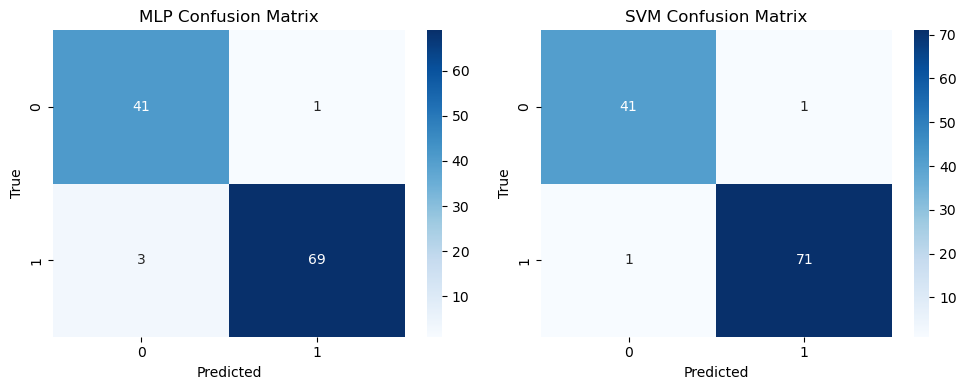

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, [("MLP", results_mlp), ("SVM", results_svm)]):
	cm = confusion_matrix(y_test, res["y_pred_test"])
	sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
	ax.set_title(f"{name} Confusion Matrix")
	ax.set_xlabel("Predicted")
	ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## Confusion matrices for both models

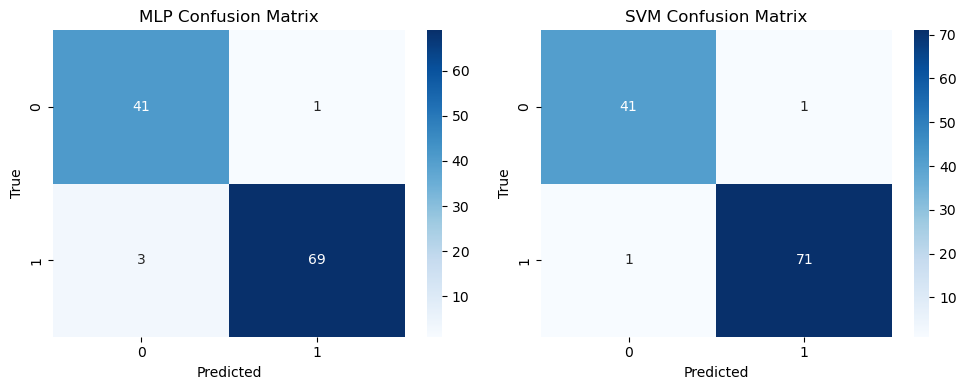

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, [("MLP", results_mlp), ("SVM", results_svm)]):
	cm = confusion_matrix(y_test, res["y_pred_test"])
	sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
	ax.set_title(f"{name} Confusion Matrix")
	ax.set_xlabel("Predicted")
	ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## ROC curves (AUC) for models

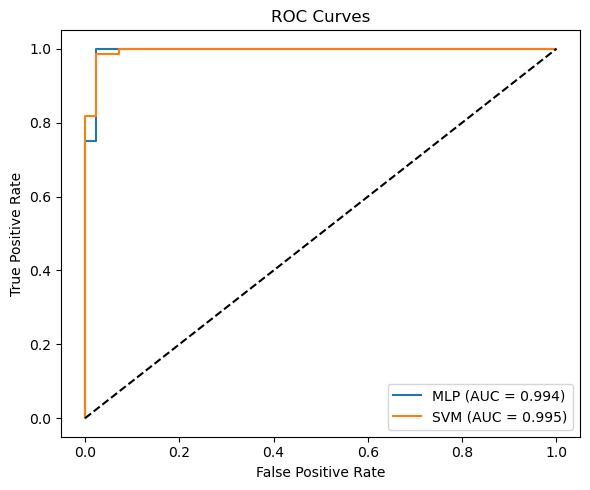

In [41]:
plt.figure(figsize=(6, 5))
for name, pipe in [("MLP", results_mlp["model"]), ("SVM", results_svm["model"])]:
	if hasattr(pipe.named_steps[list(pipe.named_steps.keys())[-1]], "predict_proba"):
		y_score = pipe.predict_proba(X_test)[:, 1]
	else:
		y_score = pipe.decision_function(X_test)
	fpr, tpr, _ = roc_curve(y_test, y_score)
	roc_auc = auc(fpr, tpr)
	plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

## PCA experiments
##  2-component visualization and PCA->95% variance comparison

In [42]:
for n_comp in (2,):
	pca_pipe = Pipeline([
		("scaler", StandardScaler()),
		("pca", PCA(n_components=n_comp)),
	])
	X_train_p = pca_pipe.fit_transform(X_train)
	X_test_p = pca_pipe.transform(X_test)

	mlp_p = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
	svm_p = SVC(kernel="rbf", probability=True, random_state=42)

	mlp_p.fit(X_train_p, y_train)
	svm_p.fit(X_train_p, y_train)

	y_mlp_p = mlp_p.predict(X_test_p)
	y_svm_p = svm_p.predict(X_test_p)

	print(f"PCA {n_comp} comps - MLP test accuracy: {accuracy_score(y_test, y_mlp_p):.4f}")
	print(f"PCA {n_comp} comps - SVM test accuracy: {accuracy_score(y_test, y_svm_p):.4f}")


PCA 2 comps - MLP test accuracy: 0.9474
PCA 2 comps - SVM test accuracy: 0.9474


## PCA explained-variance experiment (retain 95% variance)

In [43]:
pca95 = Pipeline([
	("scaler", StandardScaler()),
	("pca", PCA(n_components=0.95)),
])
X_train_95 = pca95.fit_transform(X_train)
X_test_95 = pca95.transform(X_test)

print(f"Components to explain 95% variance: {X_train_95.shape[1]}")

mlp_95 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
svm_95 = SVC(kernel="rbf", probability=True, random_state=42)

mlp_95.fit(X_train_95, y_train)
svm_95.fit(X_train_95, y_train)

print(f"MLP on PCA95 acc: {accuracy_score(y_test, mlp_95.predict(X_test_95)):.4f}")
print(f"SVM on PCA95 acc: {accuracy_score(y_test, svm_95.predict(X_test_95)):.4f}")

Components to explain 95% variance: 10
MLP on PCA95 acc: 0.9561
SVM on PCA95 acc: 0.9737
